In [1]:
import pandas as pd
from us_state_abbreviations import abbreviations, abbreviation_to_name

In [2]:
naco_achievement_db = pd.read_csv("../output/naco_achievement_database.csv")
naco_achievement_db.head()

,year,county,program,program_link,category,best_in_category
0,2023,"Citrus County, Fla.","Scripting for Security, Standardization, and S...",https://www.naco.org/resources/award-programs/...,Information Technology,False
1,2023,"Montgomery County, Md.",Kids Day Out,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False
2,2023,"Montgomery County, Md.",Let Her Shine – Girls Volleyball,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False
3,2023,"Montgomery County, Md.",Inclusion Multi-Sport Program,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False
4,2023,"Montgomery County, Md.",Case Portal for Subpoena Management,https://www.naco.org/resources/award-programs/...,NaN,False


In [3]:
naco_achievement_db.loc[:,("state_abbr2")] = naco_achievement_db["county"].apply(lambda x: x.split(", ")[-1] if isinstance(x, str) else "")

In [4]:
naco_achievement_db["state_abbr2"].unique()

array(['Fla.', 'Md.', 'Calif.', 'Ariz.', 'Ill.', 'Kan.', 'N.C.', 'Wash.',
       'Texas', 'Ohio', 'Minn.', 'Utah', 'Va.', 'Mo.', 'Wis.', 'Pa.',
       'Colo.', 'N.Y.', 'Ark.', 'N.J.', 'Del.', 'La.', '', 'N.M.',
       'New Mexico Association of Counties', 'Mich.', 'Ga.', 'Nev.',
       'S.C.', 'County Commissioners Association of Ohio', 'N.H.', 'Neb.',
       'Ind.', 'Ky.', 'Ore.', 'Iowa', 'Mont.', 'Hawaii', 'Tenn.', 'N.D.',
       'Wyo.', 'Mass.',
       'North Carolina Association of County Commissioners',
       'Alaska Municipal League', 'S.D.', 'Ala.', 'W.Va.', 'Okla.',
       'Association of Arkansas Counties',
       'South Carolina Association of Counties',
       'Association of County Commissions of Alabama', 'Idaho',
       'Iowa State Association of Counties',
       "ACCG – Advancing Georgia's Counties",
       'Washington State Association of Counties', 'Maine', 'Alaska',
       'Miss.'], dtype=object)

* likely county associations

In [5]:
county_associations = [state for state in naco_achievement_db["state_abbr2"].unique() if len(state)>6]
county_associations

['New Mexico Association of Counties',
 'County Commissioners Association of Ohio',
 'North Carolina Association of County Commissioners',
 'Alaska Municipal League',
 'Association of Arkansas Counties',
 'South Carolina Association of Counties',
 'Association of County Commissions of Alabama',
 'Iowa State Association of Counties',
 "ACCG – Advancing Georgia's Counties",
 'Washington State Association of Counties']

In [6]:
county_associations_df = naco_achievement_db[naco_achievement_db['state_abbr2'].isin(county_associations)]
print(county_associations_df.shape)
county_associations_df.head()

(14, 7)


,year,county,program,program_link,category,best_in_category,state_abbr2
492,2023,New Mexico Association of Counties,County Assessor and Treasurer Roles and Proper...,https://www.naco.org/resources/award-programs/...,Civic Education and Public Information,False,New Mexico Association of Counties
513,2023,New Mexico Association of Counties,Recognizing Excellence and Leadership (R.E.A.L...,https://www.naco.org/resources/award-programs/...,Civic Education and Public Information,True,New Mexico Association of Counties
714,2023,County Commissioners Association of Ohio,Ohio Counties: Ohio Statehouse Map Room Intera...,https://www.naco.org/resources/award-programs/...,Civic Education and Public Information,False,County Commissioners Association of Ohio
1828,2022,North Carolina Association of County Commissio...,The 5-5-5 Committee,https://www.naco.org/resources/award-programs/...,Health,False,North Carolina Association of County Commissio...
1944,2021,Alaska Municipal League,Alaska Remote Sellers Sales Tax Commission,https://www.naco.org/resources/award-programs/...,Financial Management,True,Alaska Municipal League


In [7]:
naco_achievement_db.shape

(8730, 7)

In [8]:
naco_achievement_db.loc[naco_achievement_db["county"].isna()]

,year,county,program,program_link,category,best_in_category,state_abbr2
429,2023,NaN,RURAL EMS VOLUNTEER INSURANCE,https://www.naco.org/resources/award-programs/...,Community and Economic Development,False,


In [9]:
print(naco_achievement_db.loc[naco_achievement_db["county"].isna()]["program_link"].reset_index(drop = True)[0])

https://www.naco.org/resources/award-programs/rural-ems-volunteer-insurance


* upon further research, the `"RURAL EMS VOLUNTEER INSURANCE` program appears to be a [joint venture from the Utah Association of Counties](https://www.uacnet.org/rural-ems-insurance)
* Change the state to Utah
* temporary workaround
    + remove all 14 program thats were given to county associations
* long-term workaround
    + use the county where the state capital is (Salt Lake County in the Utah example)
        + OR 
    + divide across all [29 Utah counties](https://www.uacnet.org/utah-s-29-counties)
    + this approach may be needed for association recepients like:
        + New Mexico Association of Counties'
        + County Commissioners Association of Ohio
        + North Carolina Association of County Commissioners
        + Alaska Municipal League'
        + Association of Arkansas Counties
        + South Carolina Association of Counties
        + Association of County Commissions of Alabama
        + Iowa State Association of Counties'
        + ACCG – Advancing Georgia's Counties
        + Washington State Association of Counties

In [10]:
naco_achievement_db.loc[naco_achievement_db["county"].isna(), "state_abbr2"] = "UT"

In [11]:
naco_achievement_db.loc[naco_achievement_db["county"].isna(), "county"]= "Salt Lake County"

In [12]:
naco_achievement_db.loc[naco_achievement_db["program"]==  "RURAL EMS VOLUNTEER INSURANCE"]

,year,county,program,program_link,category,best_in_category,state_abbr2
429,2023,Salt Lake County,RURAL EMS VOLUNTEER INSURANCE,https://www.naco.org/resources/award-programs/...,Community and Economic Development,False,UT


In [13]:
naco_achievement_db2 = naco_achievement_db[~naco_achievement_db['state_abbr2'].isin(county_associations)]
naco_achievement_db2.shape

(8716, 7)

In [14]:
naco_award_data = pd.read_csv("../output/award_data.csv")
naco_award_data.head()

,program,county,year,category,description,best_in_category
0,"Scripting for Security, Standardization, and S...","Citrus County, Fla., FL",2023,Information Technology,"Limited IT staff, increased staff turnover cou...",True
1,Kids Day Out,"Montgomery County, Md., MD",2023,Parks and Recreation,"Kids Day Out is a high-quality, well-organized...",True
2,Let Her Shine – Girls Volleyball,"Montgomery County, Md., MD",2023,Parks and Recreation,"As girls approach the middle school years, gen...",True
3,Inclusion Multi-Sport Program,"Montgomery County, Md., MD",2023,Parks and Recreation,Montgomery County Recreation’s (MCR) Inclusion...,True
4,Case Portal for Subpoena Management,"Montgomery County, Md., MD",2023,Array,The Department of Health and Human Services (D...,True


In [15]:
naco_award_data.loc[:,("county_name")] = naco_award_data["county"].apply(lambda x: x.split(", ")[0])
naco_award_data.loc[:,("state_abbr")] = naco_award_data["county"].apply(lambda x: x.split(", ")[-1])

In [16]:
naco_award_data.loc[:,("state_abbr")].unique()

array(['FL', 'MD', 'CA', 'AZ', 'IL', 'KS', 'NC', 'WA', 'TX', 'OH', 'MN',
       'UT', 'VA', 'MO', 'WI', 'PA', 'CO', 'NY', 'AR', 'NJ', 'DE', 'LA',
       'Array', 'NM', 'MI', 'GA', 'NV', 'SC', 'NH', 'NE', 'IN', 'KY',
       'OR', 'IA', 'MT', 'HI', 'TN', 'ND', 'WY', 'MA', 'AK', 'SD', 'AL',
       'WV', 'OK', 'ID', 'ME', 'MS'], dtype=object)

* differences between unique abbreviations and known state abbreviations 

In [17]:
list(set(naco_award_data.loc[:,("state_abbr")].unique()) - set(abbreviations))

['Array']

In [18]:
naco_award_data.loc[naco_award_data["state_abbr"]==  "Array"]

,program,county,year,category,description,best_in_category,county_name,state_abbr
429,RURAL EMS VOLUNTEER INSURANCE,"Array, Array",2023\n\n\nUtah is largely made up of rural are...,Community and Economic Development,tremendously effective.,True,Array,Array


In [19]:
naco_award_data.loc[naco_award_data["state_abbr"]==  "Array", "county_name"]= "Salt Lake County"
naco_award_data.loc[naco_award_data["state_abbr"]==  "Array", "state_abbr"]= "UT"

In [20]:
naco_award_data.loc[naco_award_data["program"]==  "RURAL EMS VOLUNTEER INSURANCE"]

,program,county,year,category,description,best_in_category,county_name,state_abbr
429,RURAL EMS VOLUNTEER INSURANCE,"Array, Array",2023\n\n\nUtah is largely made up of rural are...,Community and Economic Development,tremendously effective.,True,Salt Lake County,UT


In [21]:
naco_award_data.shape

(8730, 8)

In [22]:
naco_award_data2 = naco_award_data[~naco_award_data['program'].isin(county_associations_df["program"].unique())]
naco_award_data2.shape

(8716, 8)

In [23]:
naco_award_data2.head()

,program,county,year,category,description,best_in_category,county_name,state_abbr
0,"Scripting for Security, Standardization, and S...","Citrus County, Fla., FL",2023,Information Technology,"Limited IT staff, increased staff turnover cou...",True,Citrus County,FL
1,Kids Day Out,"Montgomery County, Md., MD",2023,Parks and Recreation,"Kids Day Out is a high-quality, well-organized...",True,Montgomery County,MD
2,Let Her Shine – Girls Volleyball,"Montgomery County, Md., MD",2023,Parks and Recreation,"As girls approach the middle school years, gen...",True,Montgomery County,MD
3,Inclusion Multi-Sport Program,"Montgomery County, Md., MD",2023,Parks and Recreation,Montgomery County Recreation’s (MCR) Inclusion...,True,Montgomery County,MD
4,Case Portal for Subpoena Management,"Montgomery County, Md., MD",2023,Array,The Department of Health and Human Services (D...,True,Montgomery County,MD


In [24]:
naco_achievement_db2[["year"]].dtypes

year    int64
dtype: object

In [25]:
naco_award_data2.loc[:,("year2")] = naco_award_data2["year"].apply(lambda x: x.split("\n\n\n")[0] if isinstance(x, str) else "")
naco_award_data2.loc[:,("description2")] = naco_award_data2["year"].apply(lambda x: x.split("\n\n\n")[-1] if isinstance(x, str) else "")

/var/folders/g1/b0_nqq_d1hg81gvzq4zj7h8r0000gn/T/ipykernel_2766/3370750419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naco_award_data2.loc[:,("year2")] = naco_award_data2["year"].apply(lambda x: x.split("\n\n\n")[0] if isinstance(x, str) else "")
/var/folders/g1/b0_nqq_d1hg81gvzq4zj7h8r0000gn/T/ipykernel_2766/3370750419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naco_award_data2.loc[:,("description2")] = naco_award_data2["year"].apply(lambda x: x.split("\n\n\n")[-1] if isinstance(x, str) e

In [26]:
len(naco_award_data2["description"].unique())

8663

In [27]:
naco_award_data2["description2"].unique()

array(['2023',
       'The Healthy Lifestyle in Residential Communities Project was part of the Howard County Local Health Improvement Coalition (HCLHIC)â€™s new effort to strengthen community partnerships using a place-based approach with targeted outreach and education in identified residential communities to address diabetes and improve health equity in Howard County. \nEight residential communities were selected for this new pilot project based on data review and prioritization of low-income residents and those facing barriers to healthcare. Project implementation occurred between June and December 2022 and engaged residents from youths to seniors of various races and ethnicities representing Howard Countyâ€™s diverse communities. Through collaboration with HCLHIC partners and Howard County Government agencies, free on-site sessions and events were held to promote physical activity, healthy eating, and connection to community resources. \nThis project engaged twelve diverse communi

In [28]:
len(naco_award_data2["year2"].unique())

16

In [29]:
naco_award_data2["year2"].unique()

array(['2023', '2022', '2021', '2020', '2019', '2018', '', '2017', '2016',
       '2015', '2014', '2013', '2012', '2011', '2010', '2009'],
      dtype=object)

In [30]:
import numpy as np

In [31]:
naco_award_data2.reset_index(inplace=True)

In [32]:
for row in range(0, naco_award_data2.shape[0]):
#     print(naco_award_data2["year2"][row])
#     print(row)
    if naco_award_data2["year2"][row] == "":
        naco_award_data2["year2"][row] = naco_award_data2["description"][row]
        naco_award_data2["description"][row] = ""
        print(naco_award_data2["year2"][row])
#     print(row)

2018
2018
2018
2018
2018
2018
2015
2015
2011
2011
2011
2011
2011


/var/folders/g1/b0_nqq_d1hg81gvzq4zj7h8r0000gn/T/ipykernel_2766/4049697743.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naco_award_data2["year2"][row] = naco_award_data2["description"][row]
/var/folders/g1/b0_nqq_d1hg81gvzq4zj7h8r0000gn/T/ipykernel_2766/4049697743.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naco_award_data2["description"][row] = ""
/var/folders/g1/b0_nqq_d1hg81gvzq4zj7h8r0000gn/T/ipykernel_2766/4049697743.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [33]:
naco_award_data2["year2"].unique()

array(['2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016',
       '2015', '2014', '2013', '2012', '2011', '2010', '2009'],
      dtype=object)

In [34]:
naco_award_data2.head()

,index,program,county,year,category,description,best_in_category,county_name,state_abbr,year2,description2
0,0,"Scripting for Security, Standardization, and S...","Citrus County, Fla., FL",2023,Information Technology,"Limited IT staff, increased staff turnover cou...",True,Citrus County,FL,2023,2023
1,1,Kids Day Out,"Montgomery County, Md., MD",2023,Parks and Recreation,"Kids Day Out is a high-quality, well-organized...",True,Montgomery County,MD,2023,2023
2,2,Let Her Shine – Girls Volleyball,"Montgomery County, Md., MD",2023,Parks and Recreation,"As girls approach the middle school years, gen...",True,Montgomery County,MD,2023,2023
3,3,Inclusion Multi-Sport Program,"Montgomery County, Md., MD",2023,Parks and Recreation,Montgomery County Recreation’s (MCR) Inclusion...,True,Montgomery County,MD,2023,2023
4,4,Case Portal for Subpoena Management,"Montgomery County, Md., MD",2023,Array,The Department of Health and Human Services (D...,True,Montgomery County,MD,2023,2023


In [35]:
naco_award_data2.loc[naco_award_data2["year2"]==""]

,index,program,county,year,category,description,best_in_category,county_name,state_abbr,year2,description2


In [36]:
naco_award_data2["year2"].unique()

array(['2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016',
       '2015', '2014', '2013', '2012', '2011', '2010', '2009'],
      dtype=object)

In [37]:
naco_award_data2.loc[:,("year2")] = naco_award_data2[["year2"]].apply(pd.to_numeric)

In [38]:
naco_award_data2["year2"]

0       2023
1       2023
2       2023
3       2023
4       2023
        ... 
8711    2009
8712    2009
8713    2009
8714    2009
8715    2009
Name: year2, Length: 8716, dtype: object

In [39]:
naco_achievement_db2["year"]

0       2023
1       2023
2       2023
3       2023
4       2023
        ... 
8725    2009
8726    2009
8727    2009
8728    2009
8729    2009
Name: year, Length: 8716, dtype: int64

In [40]:
naco_achievement_db2.columns

Index(['year', 'county', 'program', 'program_link', 'category',
       'best_in_category', 'state_abbr2'],
      dtype='object')

In [41]:
naco_achievement_db2.head()

,year,county,program,program_link,category,best_in_category,state_abbr2
0,2023,"Citrus County, Fla.","Scripting for Security, Standardization, and S...",https://www.naco.org/resources/award-programs/...,Information Technology,False,Fla.
1,2023,"Montgomery County, Md.",Kids Day Out,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,Md.
2,2023,"Montgomery County, Md.",Let Her Shine – Girls Volleyball,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,Md.
3,2023,"Montgomery County, Md.",Inclusion Multi-Sport Program,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,Md.
4,2023,"Montgomery County, Md.",Case Portal for Subpoena Management,https://www.naco.org/resources/award-programs/...,NaN,False,Md.


In [42]:
naco_award_data2.columns

Index(['index', 'program', 'county', 'year', 'category', 'description',
       'best_in_category', 'county_name', 'state_abbr', 'year2',
       'description2'],
      dtype='object')

In [43]:
naco_award_data2.head()

,index,program,county,year,category,description,best_in_category,county_name,state_abbr,year2,description2
0,0,"Scripting for Security, Standardization, and S...","Citrus County, Fla., FL",2023,Information Technology,"Limited IT staff, increased staff turnover cou...",True,Citrus County,FL,2023,2023
1,1,Kids Day Out,"Montgomery County, Md., MD",2023,Parks and Recreation,"Kids Day Out is a high-quality, well-organized...",True,Montgomery County,MD,2023,2023
2,2,Let Her Shine – Girls Volleyball,"Montgomery County, Md., MD",2023,Parks and Recreation,"As girls approach the middle school years, gen...",True,Montgomery County,MD,2023,2023
3,3,Inclusion Multi-Sport Program,"Montgomery County, Md., MD",2023,Parks and Recreation,Montgomery County Recreation’s (MCR) Inclusion...,True,Montgomery County,MD,2023,2023
4,4,Case Portal for Subpoena Management,"Montgomery County, Md., MD",2023,Array,The Department of Health and Human Services (D...,True,Montgomery County,MD,2023,2023


In [44]:
award_cols = ['program', 'description', 'county_name', 'state_abbr', 'year2']
db_cols = ['year', 'program', 'program_link', 'category', 'best_in_category']

In [45]:
# Find duplicate rows
naco_award_data2_dupes = naco_award_data2[naco_award_data2.program.duplicated()]
print(naco_award_data2_dupes.shape)
naco_award_data2_dupes.head()

(18, 11)


,index,program,county,year,category,description,best_in_category,county_name,state_abbr,year2,description2
120,120,Digitization of County Contracting,"Montgomery County, Md., MD",2023\n\n\nAll levels of government are working...,County Administration and Management,"For decades, the County'™s Office of Procureme...",True,Montgomery County,MD,2023,All levels of government are working to reduce...
1051,1054,Harriet Tubman Cultural Center,"Howard County, Md., MD",2023\n\n\nThe Harriet Tubman School opened in ...,"Arts, Culture and Historic Preservation",The Department of Public Works managed the ful...,False,Howard County,MD,2023,"The Harriet Tubman School opened in 1949, in a..."
1066,1069,"""Flow Through Summer"" Youth Mindfulness Program","Douglas County, Neb., NE",2023,Children and Youth,"In the spring of 2022, the founders of HERE pa...",False,Douglas County,NE,2023,2023
1433,1436,Bridging the Digital Divide for Older Adults,"Orange County, Calif., CA",2022\n\n\nBridging the Digital Divide for Olde...,Human Services,The program was created and launched in Septem...,True,Orange County,CA,2022,Bridging the Digital Divide for Older Adults (...
1442,1445,Connecting All Community Residents to Public S...,"Chesterfield County, Va., VA",2022,Civic Education and Public Information,Public schools don'™t exist in a vacuum. In th...,True,Chesterfield County,VA,2022,2022


In [46]:
# Find duplicate rows
naco_achievement_db2_dupes = naco_achievement_db2[naco_achievement_db2.program.duplicated()]
print(naco_achievement_db2_dupes.shape)
naco_achievement_db2_dupes.head()

(18, 7)


,year,county,program,program_link,category,best_in_category,state_abbr2
120,2023,"Montgomery County, Md.",Digitization of County Contracting,https://www.naco.org/resources/award-programs/...,County Administration and Management,False,Md.
1054,2023,"Howard County, Md.",Harriet Tubman Cultural Center,https://www.naco.org/resources/award-programs/...,"Arts, Culture and Historic Preservation",False,Md.
1069,2023,"Douglas County, Neb.","""Flow Through Summer"" Youth Mindfulness Program",https://www.naco.org/resources/award-programs/...,Children and Youth,False,Neb.
1436,2022,"Orange County, Calif.",Bridging the Digital Divide for Older Adults,https://www.naco.org/resources/award-programs/...,Human Services,False,Calif.
1445,2022,"Chesterfield County, Va.",Connecting All Community Residents to Public S...,https://www.naco.org/resources/award-programs/...,Civic Education and Public Information,False,Va.


In [47]:
naco_achievement_db2 = naco_achievement_db2[~naco_achievement_db2.program.duplicated()]
naco_award_data2 = naco_award_data2[~naco_award_data2.program.duplicated()]


In [48]:
merged_df = naco_achievement_db2[db_cols].merge(naco_award_data2[award_cols],
                                       left_on= ["program", "year"],
                                       right_on= ["program", "year2"])

In [49]:
merged_df.reset_index(inplace=True, drop=True)
merged_df = merged_df[["year", "program", "program_link", "category", "best_in_category",
         "description", "county_name", "state_abbr"]]
merged_df.head()

,year,program,program_link,category,best_in_category,description,county_name,state_abbr
0,2023,"Scripting for Security, Standardization, and S...",https://www.naco.org/resources/award-programs/...,Information Technology,False,"Limited IT staff, increased staff turnover cou...",Citrus County,FL
1,2023,Kids Day Out,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,"Kids Day Out is a high-quality, well-organized...",Montgomery County,MD
2,2023,Let Her Shine – Girls Volleyball,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,"As girls approach the middle school years, gen...",Montgomery County,MD
3,2023,Inclusion Multi-Sport Program,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,Montgomery County Recreation’s (MCR) Inclusion...,Montgomery County,MD
4,2023,Case Portal for Subpoena Management,https://www.naco.org/resources/award-programs/...,NaN,False,The Department of Health and Human Services (D...,Montgomery County,MD


In [50]:
print(merged_df.shape)

(8698, 8)


In [51]:
# Find duplicate rows
merged_df_duplicates = merged_df[merged_df.program.duplicated()]

In [52]:
merged_df_duplicates.shape

(0, 8)

In [53]:
merged_df_duplicates.head()

,year,program,program_link,category,best_in_category,description,county_name,state_abbr


In [54]:
merged_df.reset_index(inplace=True, drop = True)
print(merged_df.shape)

(8698, 8)


In [55]:
len(merged_df["description"].unique())

8654

In [56]:
merged_df.loc[merged_df["program"]=="Digitization of County Contracting"]

,year,program,program_link,category,best_in_category,description,county_name,state_abbr
107,2023,Digitization of County Contracting,https://www.naco.org/resources/award-programs/...,County Administration and Management,False,"For decades, the County'™s Office of Procureme...",Montgomery County,MD


In [57]:
merged_df.head()

,year,program,program_link,category,best_in_category,description,county_name,state_abbr
0,2023,"Scripting for Security, Standardization, and S...",https://www.naco.org/resources/award-programs/...,Information Technology,False,"Limited IT staff, increased staff turnover cou...",Citrus County,FL
1,2023,Kids Day Out,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,"Kids Day Out is a high-quality, well-organized...",Montgomery County,MD
2,2023,Let Her Shine – Girls Volleyball,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,"As girls approach the middle school years, gen...",Montgomery County,MD
3,2023,Inclusion Multi-Sport Program,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False,Montgomery County Recreation’s (MCR) Inclusion...,Montgomery County,MD
4,2023,Case Portal for Subpoena Management,https://www.naco.org/resources/award-programs/...,NaN,False,The Department of Health and Human Services (D...,Montgomery County,MD


In [58]:
merged_df["county_name"].value_counts()

county_name
San Bernardino County    678
Los Angeles County       649
San Diego County         631
Maricopa County          565
Miami-Dade County        513
                        ... 
Arapahoe County            1
Josephine County           1
Giles County               1
Bossier Parish             1
Colusa County              1
Name: count, Length: 383, dtype: int64

* winning submissions by county

In [73]:
merged_df.loc[merged_df["best_in_category"] == True]["county_name"].value_counts()

county_name
Los Angeles County       34
San Bernardino County    31
San Diego County         26
Montgomery County        25
Maricopa County          24
                         ..
Monongalia County         1
Jefferson County          1
Tarrant County            1
Wilson County             1
Brunswick County          1
Name: count, Length: 148, dtype: int64

In [59]:
merged_df["year"].value_counts(sort=True)

year
2023    1066
2022     865
2021     794
2018     599
2019     597
2016     586
2017     569
2015     520
2020     502
2009     482
2014     468
2010     464
2012     416
2011     413
2013     357
Name: count, dtype: int64

In [60]:
merged_df["state_abbr"].value_counts()

state_abbr
CA    2452
FL    1238
VA     892
MD     692
AZ     616
NC     497
MI     355
MN     260
CO     239
GA     210
OH     152
IL     146
NY     138
TX     131
OR      95
WA      68
PA      57
UT      44
KS      41
NV      41
SC      41
NM      39
KY      38
NJ      36
WI      30
LA      24
MO      21
IA      13
HI      12
TN      10
AL      10
NE       7
MT       7
DE       6
WV       5
NH       5
IN       4
AK       4
MS       4
ND       3
SD       3
OK       3
ME       3
WY       2
ID       2
MA       1
AR       1
Name: count, dtype: int64

In [61]:
merged_df["best_in_category"].value_counts()

best_in_category
False    8189
True      509
Name: count, dtype: int64

In [62]:
pd.crosstab(merged_df.state_abbr,
            merged_df.best_in_category, normalize='index')

best_in_category,False,True
state_abbr,,
AK,1.000000,0.000000
AL,0.800000,0.200000
AR,1.000000,0.000000
AZ,0.956169,0.043831
CA,0.948613,0.051387
CO,0.920502,0.079498
DE,1.000000,0.000000
FL,0.947496,0.052504
GA,0.919048,0.080952


In [63]:
pd.crosstab(merged_df.category,
            merged_df.best_in_category, normalize='index')

best_in_category,False,True
category,,
"Arts, Culture and Historic Preservation",0.892216,0.107784
Children and Youth,0.949627,0.050373
Civic Education and Public Information,0.947455,0.052545
Community and Economic Development,0.942801,0.057199
County Administration and Management,0.932727,0.067273
County Resiliency,0.937626,0.062374
Criminal Justice and Public Safety,0.937913,0.062087
Financial Management,0.897260,0.102740
Health,0.954930,0.045070


<AxesSubplot:>

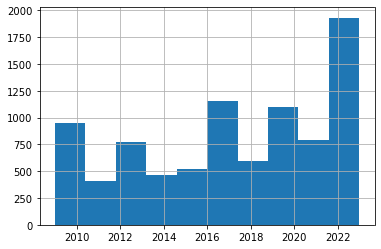

In [64]:
merged_df["year"].hist()

In [65]:
merged_df.to_csv("../output/merged_naco_achievement_data.csv", index=False)

In [66]:
import sys
from datetime import datetime
print(f'last updated: {datetime.now().strftime("%Y-%m-%d %H:%M")} \n')
print(f"System and module version information: \n")
print(f"Python version: {sys.version_info}")
print(f"pandas version: {pd.__version__}")

last updated: 2024-06-09 14:29 

System and module version information: 

Python version: sys.version_info(major=3, minor=9, micro=7, releaselevel='final', serial=0)
pandas version: 2.0.3
